# TLM-accelerated Sentinel-2 time series via STAC

If TLM headers are present in JPEG2000s (JP2, the file format in which Sentinel-2 is saved on CDSE), only two requests are necessary to get a smaller block from the file. 

TLM headers basically announce where contiguous chunks of data are present within the file.

However up until the 5th of February 2026 these headers were not generated for Sentinel 2 products. Because of this, when trying to access only small parts of a Sentinel-2 file, the full file structure first has to be discovered sequentially, jumping from block to block. This takes a lot of requests.

A solution could be to pre-generate the TLM headers for older Sentinel products, and distribute them alongside the products. They can then be injected when reading, potentially cutting the number of necessary requests by two magnitudes (from around 100 to 3 requests).

This notebook tests how much this would speed up access of Sentinel-2 data from the CDSE S3 bucket.


## Setup

Since all of this is very experimental, no real tooling exists around the use-case. This notebook builds on existing work which implements a JP2 codec for reading JP2 data into zarr stores.

It also uses kerchunk and virtualizarr to build a virtual zarr store, backed by the actual JP2 data on the bucket.

In [1]:
import pickle

import boto3
from obstore.store import S3Store
from pyproj import Transformer
from virtualizarr.manifests.store import ObjectStoreRegistry

import jp2io.zarr.codec  # noqa: F401  -- registers the JPEG2000 codec (needed before reading)
from jp2io import stac
from jp2io.provider import ParquetTLMProvider
from jp2io.zarr.virtualizarr import CDSE_ENDPOINT

## Area of interest

We reuse the shared AOI (`../params.pkl`) — a 10 km box near 14.40°E, 47.04°N, full-year 2021. It falls inside MGRS tile **33TVN** (UTM zone 33N, EPSG:32633).

For this tile we have already pre-computed all TLM headers from the start of the Sentinel time-series up to the date where TLM headers are generated on the products themselves.

Spatial subsetting here takes bounds in the **tile's UTM CRS**, so we reproject the WGS84 bbox into EPSG:32633.


In [2]:
MGRS_TILE = "33TVN"
UTM_EPSG = 32633  # UTM zone 33N

with open("../params.pkl", "rb") as fp:
    p = pickle.load(fp)

to_utm = Transformer.from_crs("EPSG:4326", f"EPSG:{UTM_EPSG}", always_xy=True)
minx, miny, maxx, maxy = p["box_4326"].bounds
bounds = (*to_utm.transform(minx, miny), *to_utm.transform(maxx, maxy))

datetime = f"{p['start']}/{p['end']}"
datetime, bounds

('2021-01-01/2022-01-01',
 (449030.2565467731, 5204447.577367328, 459657.82505819947, 5214944.124667359))

## Credentials

The JP2 reads go against the CDSE `eodata` S3 bucket; credentials come from an AWS profile (here `eodata`). The STAC search itself is anonymous.


In [3]:
frozen = boto3.Session(profile_name="eodata").get_credentials().get_frozen_credentials()


def credential_provider() -> dict:
    # obstore expects all four keys, even without a session token
    return {
        "access_key_id": frozen.access_key,
        "secret_access_key": frozen.secret_key,
        "token": frozen.token,
        "expires_at": None,
    }


store = S3Store(
    bucket="eodata",
    config={"endpoint": CDSE_ENDPOINT},
    credential_provider=credential_provider,
)
registry = ObjectStoreRegistry({"s3://eodata": store})

## Build the cube from a STAC query

`stac.search` injects the `grid:code` tile filter, runs the query, intersects the results with the TLM index, and returns the cube plus the matched / missing product ids. 

Compared to other solutions we've seen so far, this is very bare-bones. There's no mosaicing, no reprojecting and at the moment it only works for assets which have a TLM available in the TLM parquet.

This is more of a tech demo than anything else.

In [4]:
%%time
provider = ParquetTLMProvider.from_local_file("33TVN.parquet")

result = stac.search(
    MGRS_TILE,
    tlm_provider=provider,
    store_registry=registry,
    datetime=datetime,
    query={"eo:cloud_cover": {"lte": 80}},
    bands=["B08", "B11", "SCL", "AOT"],
    bounds=bounds,
    chunks={},  # lazy, dask-backed
)

print(f"{len(result.matched_ids)} products have a TLM index (the cube's time steps)")
print(f"{len(result.missing_ids)} STAC products were skipped (no TLM index)")
result.datatree

90 products have a TLM index (the cube's time steps)
0 STAC products were skipped (no TLM index)
CPU times: user 2.55 s, sys: 715 ms, total: 3.26 s
Wall time: 7.83 s


<xarray.DataTree>
Group: /
│   Attributes:
│       product_ids:  ['S2A_MSIL2A_20210103T101411_N0500_R022_T33TVN_20230306T172...
├── Group: /measurements
│   └── Group: /measurements/reflectance
│       ├── Group: /measurements/reflectance/r10m
│       │       Dimensions:  (time: 90, y: 1049, x: 1063)
│       │       Coordinates:
│       │         * time     (time) datetime64[us] 720B 2021-01-03T10:14:11 ... 2021-12-31T10...
│       │         * y        (y) float64 8kB 5.215e+06 5.215e+06 ... 5.204e+06 5.204e+06
│       │         * x        (x) float64 9kB 4.49e+05 4.49e+05 4.491e+05 ... 4.596e+05 4.597e+05
│       │       Data variables:
│       │           b08      (time, y, x) uint16 201MB dask.array<chunksize=(1, 706, 213), meta=np.ndarray>
│       │       Attributes:
│       │           proj:epsg:  32633
│       └── Group: /measurements/reflectance/r20m
│               Dimensions:  (time: 90, y: 525, x: 531)
│               Coordinates:
│                 * time     (time) datetime64[us] 720B 2021-01-03T10:14:11 ... 2021-12-31T10...
│                 * y        (y) float64 4kB 5.215e+06 5.215e+06 ... 5.204e+06 5.204e+06
│                 * x        (x) float64 4kB 4.49e+05 4.491e+05 ... 4.596e+05 4.596e+05
│               Data variables:
│                   b11      (time, y, x) uint16 50MB dask.array<chunksize=(1, 225, 106), meta=np.ndarray>
│               Attributes:
│                   proj:epsg:  32633
└── Group: /conditions
    └── Group: /conditions/mask
        └── Group: /conditions/mask/l2a_classification
            └── Group: /conditions/mask/l2a_classification/r20m
                    Dimensions:  (time: 90, y: 525, x: 531)
                    Coordinates:
                      * time     (time) datetime64[us] 720B 2021-01-03T10:14:11 ... 2021-12-31T10...
                      * y        (y) float64 4kB 5.215e+06 5.215e+06 ... 5.204e+06 5.204e+06
                      * x        (x) float64 4kB 4.49e+05 4.491e+05 ... 4.596e+05 4.596e+05
                    Data variables:
                        scl      (time, y, x) uint8 25MB dask.array<chunksize=(1, 225, 106), meta=np.ndarray>
                    Attributes:
                        proj:epsg:  32633

Compared to other solutions we've seen so far, this one tries to mirror the EOPF layout which is currently proposed for Sentinel-2's eventual move from the SAFE format to zarr. This format is a datatree which holds data from different resolutions in a single data structure. In this case the datatree is still virtual, no satellite data was queried yet.

The around 8 seconds this took was mostly the query to the STAC catalog, necessary to build the datatree.


## Getting data

In [5]:
%%time
computed = result.datatree.compute(scheduler="threads", num_workers=32)

CPU times: user 1min 49s, sys: 3.21 s, total: 1min 52s
Wall time: 1min 30s


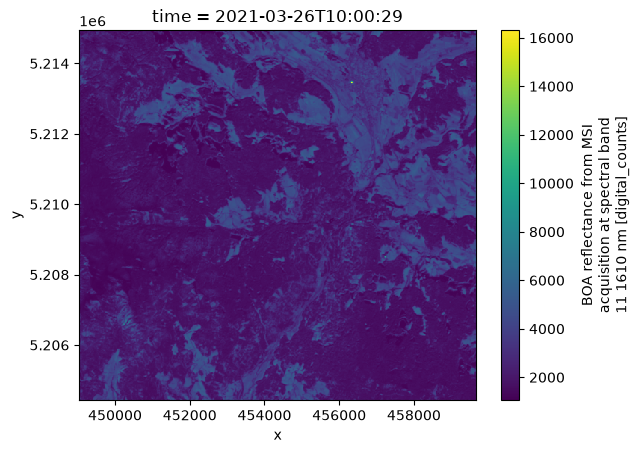

In [14]:
computed["measurements/reflectance/r20m"]["b11"].isel(time=22).plot();

And indeed, compared to other local solutions we've seen so far, this is very fast. 

We are cheating just a little bit by not carrying out any reprojection and mosaicing, and by already having the TLM markers available locally. In a real access scenario these markers would also have to be transmitted from a server. However the size of them is just a few kb per asset, which shouldn't slow down the data access much.

Unfortunately this is really not operational at the moment, but it shows a future we could have; where local access to Sentinel data subsets is fast and streamlined. The biggest hurdle is how to efficiently distribute the pre-computed TLM markers, good tooling to make use of these markers and of course institutional buy in to make it actually happen.